In [ ]:
from trainer_tools.all import Trainer, configure_logging
from trainer_tools.hooks import BatchTransformHook, ProgressBarHook, MetricsHook, LRSchedulerHook, AMPHook, GradClipHook, CheckpointHook
from trainer_tools.hooks.metrics import Loss, Accuracy, SamplesPerSecond
from trainer_tools.imports import *
from graph_attention.all import *

In [ ]:
configure_logging()

<RootLogger root (INFO)>

In [ ]:
BS = 64
variant = 'imagenette'

ds = get_dataset(variant, root="../data", train=True)
valid_ds = get_dataset(variant, root="../data", train=False)
# in notebook persistent_workers=False will cause some weird error messages about child processes
train_dl = DataLoader(ds, batch_size=BS, shuffle=True, num_workers=4, persistent_workers=True)
valid_dl = DataLoader(valid_ds, batch_size=BS, shuffle=False, num_workers=4, persistent_workers=True)
batch_x_transforms = get_batch_transforms(variant, len(ds.classes))
batch_x_transforms_valid = get_batch_transforms(variant, len(ds.classes), train=False)

In [ ]:
batch_x_transforms, batch_x_transforms_valid

(Compose(
       Compose(    RandomHorizontalFlip(p=0.5))
       ToDtype(scale=True)
       Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
 ),
 Compose(
       ToDtype(scale=True)
       Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
 ))

In [ ]:
EPOCHS = 5 #30
LR = 1e-3
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 500
GRAD_CLIP_MAX_NORM = 1.0
AMP_ENABLED = True
CHECKPOINT_EVERY = 1000
SAVE_DIR = "../checkpoints/vit_cifar10"

model = SimpleViT(
    image_size=224,
    patch_size=16,
    num_classes=len(ds.classes),
    dim=192,
    depth=12,
    num_heads=3,
    mlp_ratio=4,
    attention_layer=partial(AGFAttention, top_k=64, order=3)
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [ ]:
loss_func = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

total_steps = len(train_dl) * EPOCHS


scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    total_steps=len(train_dl) * EPOCHS,
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=10.0,
    final_div_factor=100.0,
)

hooks = [
    ProgressBarHook(),
    BatchTransformHook(x_tfm=batch_x_transforms, x_tfms_valid=batch_x_transforms_valid), 
    MetricsHook(metrics=[Loss(), Accuracy(), SamplesPerSecond()], verbose=True),
    LRSchedulerHook(scheduler),
    AMPHook(enabled=AMP_ENABLED, dtype=torch.bfloat16),
    GradClipHook(max_norm=GRAD_CLIP_MAX_NORM),
    CheckpointHook(save_dir=SAVE_DIR, save_every_steps=CHECKPOINT_EVERY, keep_last=3),
]

trainer = Trainer(
    model=model, train_dl=train_dl, valid_dl=valid_dl, optim=optimizer, loss_func=loss_func, epochs=EPOCHS, hooks=hooks
)

In [ ]:
trainer.fit()

00:49:04 [INFO] trainer_tools.hooks.optimization: Mixed Precision Training: Enabled


Epoch:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/5 [Valid]:   0%|          | 0/62 [00:00<?, ?it/s]

00:49:36 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 1/5 | samples_per_second: 393.1795 | train_accuracy: 0.2879 | train_loss: 2.0643 | valid_accuracy: 0.3497 | valid_loss: 1.9173


...

Epoch 4/5 [Valid]:   0%|          | 0/62 [00:00<?, ?it/s]

00:51:10 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 4/5 | samples_per_second: 387.7561 | train_accuracy: 0.5158 | train_loss: 1.6127 | valid_accuracy: 0.5725 | valid_loss: 1.4915


Epoch 5/5 [Train]:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 5/5 [Valid]:   0%|          | 0/62 [00:00<?, ?it/s]

00:51:41 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 5/5 | samples_per_second: 387.8464 | train_accuracy: 0.5553 | train_loss: 1.5313 | valid_accuracy: 0.6035 | valid_loss: 1.4405
00:51:42 [INFO] trainer_tools.hooks.checkpoint: Saved checkpoint: ../checkpoints/vit_cifar10/model_final.pt
00:51:42 [INFO] trainer_tools.checkpoint: Saved model to ../checkpoints/vit_cifar10/model.pt


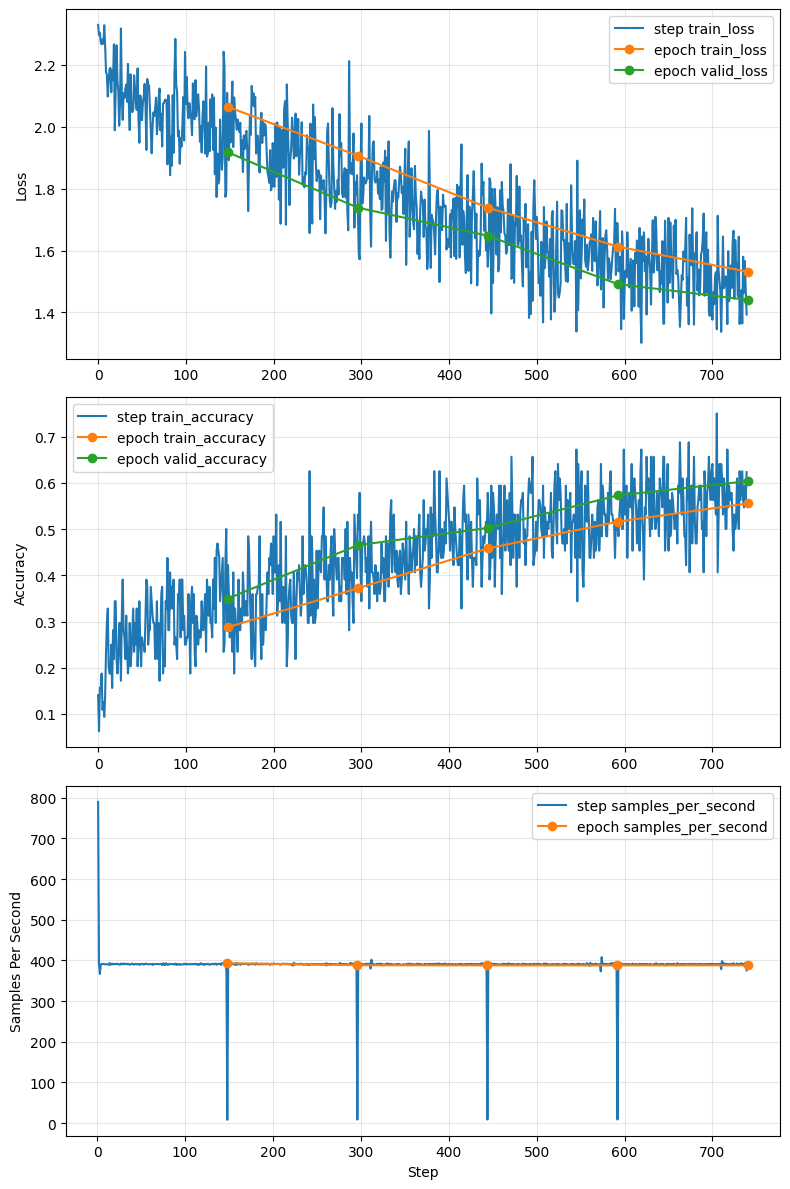

In [ ]:
trainer.get_hook(MetricsHook).plot(metrics = ["loss", "accuracy", "samples_per_second"], show_epochs=True)